#### PTB-XL CNN + BiLSTM + Attention Training
This notebook trains the ECG modality using:
CNN → BiLSTM → Temporal Attention
The EDA and preprocessing pipelines are unchanged.
Input:
12-lead ECG
100 Hz
10 seconds
1000 samples
Tasks:
1. Diagnostic superclass prediction
2. Rhythm prediction

In [1]:
from pathlib import Path
import copy
import json
import random
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    100
)

pd.set_option(
    "display.width",
    160
)

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
expected_python = None

for candidate in [repo_root, *repo_root.parents]:
    venv_python = candidate / "ml-service" / ".venv-cardio" / "Scripts" / "python.exe"
    if venv_python.exists():
        expected_python = venv_python.resolve()
        break

if expected_python is not None and Path(sys.executable).resolve() != expected_python:
    raise RuntimeError(
        "This notebook must run with the project venv at ml-service/.venv-cardio.\n"
        f"Current interpreter: {sys.executable}\n"
        f"Expected interpreter: {expected_python}\n"
        "Select the project venv in the notebook kernel picker or set the workspace default interpreter."
    )

print(f"Using interpreter: {sys.executable}")
print("Project venv check passed.")


Using interpreter: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\.venv-cardio\Scripts\python.exe
Project venv check passed.


In [3]:
print(
    "PyTorch version:",
    torch.__version__
)

print(
    "CUDA available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA version:",
        torch.version.cuda
    )

PyTorch version: 2.14.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA version: 13.0


In [4]:
SEED = 42


def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

print(
    "Seed:",
    SEED
)

Seed: 42


In [5]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Training device:",
    DEVICE
)

Training device: cuda


In [6]:
PROJECT_ROOT = (
    Path("../../../")
    .resolve()
)

print(
    "Project root:"
)

print(
    PROJECT_ROOT
)

Project root:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service


In [7]:
if str(PROJECT_ROOT) not in sys.path:

    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

print(
    "Project root added to sys.path."
)

Project root added to sys.path.


In [8]:
PREPROCESSING_VERSION = (
    "100hz_record_zscore"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ecg"
    / "ptbxl"
    / PREPROCESSING_VERSION
)

MANIFEST_PATH = (
    PROCESSED_DIR
    / "manifests"
    / "ptbxl_manifest.csv"
)

PREPROCESSING_CONFIG_PATH = (
    PROCESSED_DIR
    / "preprocessing_config.json"
)

print(
    "Processed directory:"
)

print(
    PROCESSED_DIR
)

print(
    "\nManifest:"
)

print(
    MANIFEST_PATH
)

print(
    "\nManifest exists:",
    MANIFEST_PATH.exists()
)

Processed directory:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore

Manifest:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore\manifests\ptbxl_manifest.csv

Manifest exists: True


In [9]:
if not PROCESSED_DIR.exists():

    raise FileNotFoundError(
        f"Processed directory not found:\n"
        f"{PROCESSED_DIR}"
    )


if not MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Manifest not found:\n"
        f"{MANIFEST_PATH}"
    )


if not PREPROCESSING_CONFIG_PATH.exists():

    raise FileNotFoundError(
        f"Preprocessing configuration not found:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )


print(
    "Preprocessing outputs found."
)

Preprocessing outputs found.


In [10]:
with open(
    PREPROCESSING_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as f:

    preprocessing_config = json.load(f)


print(
    json.dumps(
        preprocessing_config,
        indent=2
    )
)

{
  "dataset": "PTB-XL",
  "version_name": "100hz_record_zscore",
  "random_seed": 42,
  "source_waveform": "filename_lr",
  "sampling": {
    "target_fs_hz": 100,
    "duration_seconds": 10,
    "target_length": 1000
  },
  "signal": {
    "num_leads": 12,
    "lead_names": [
      "I",
      "II",
      "III",
      "AVR",
      "AVL",
      "AVF",
      "V1",
      "V2",
      "V3",
      "V4",
      "V5",
      "V6"
    ]
  },
  "filter": {
    "enabled": true,
    "type": "butterworth_highpass",
    "cutoff_hz": 0.5,
    "order": 3,
    "zero_phase": true
  },
  "resampling": {
    "method": "scipy.signal.resample_poly"
  },
  "length_policy": {
    "mode": "strict",
    "truncate": false,
    "zero_pad": false
  },
  "normalization": {
    "mode": "train_global_zscore",
    "epsilon": 1e-08,
    "statistics_source": "train_only"
  },
  "split": {
    "train_folds": [
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8
    ],
    "validation_folds": [
      9
  

In [11]:
ptbxl = pd.read_csv(
    MANIFEST_PATH
)

print(
    "Manifest shape:",
    ptbxl.shape
)

display(
    ptbxl.head()
)

Manifest shape: (21837, 25)


,ecg_id,patient_id,record_name,processed_path,split,strat_fold,original_fs,original_shape,resampled_shape,final_shape,final_dtype,NORM,MI,STTC,CD,HYP,RHYTHM_SR,RHYTHM_AFIB,RHYTHM_AFLT,RHYTHM_STACH,RHYTHM_SBRAD,RHYTHM_SARRH,RHYTHM_PSVT,RHYTHM_BIGU,RHYTHM_PACE
0,1,15709,records100/00000/00001_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,3,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,13243,records100/00000/00002_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,2,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,20372,records100/00000/00003_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,5,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,17014,records100/00000/00004_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,3,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,17448,records100/00000/00005_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,4,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
print(
    "Manifest columns:"
)

for column in ptbxl.columns:

    print(
        column
    )

Manifest columns:
ecg_id
patient_id
record_name
processed_path
split
strat_fold
original_fs
original_shape
resampled_shape
final_shape
final_dtype
NORM
MI
STTC
CD
HYP
RHYTHM_SR
RHYTHM_AFIB
RHYTHM_AFLT
RHYTHM_STACH
RHYTHM_SBRAD
RHYTHM_SARRH
RHYTHM_PSVT
RHYTHM_BIGU
RHYTHM_PACE


In [13]:
DIAGNOSTIC_LABELS = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP",
]


diagnostic_targets = [
    label
    for label in DIAGNOSTIC_LABELS
    if label in ptbxl.columns
]


rhythm_targets = [
    column
    for column in ptbxl.columns
    if column.startswith(
        "RHYTHM_"
    )
]


print(
    "Diagnostic targets:"
)

print(
    diagnostic_targets
)

print(
    "\nRhythm targets:"
)

print(
    rhythm_targets
)

Diagnostic targets:
['NORM', 'MI', 'STTC', 'CD', 'HYP']

Rhythm targets:
['RHYTHM_SR', 'RHYTHM_AFIB', 'RHYTHM_AFLT', 'RHYTHM_STACH', 'RHYTHM_SBRAD', 'RHYTHM_SARRH', 'RHYTHM_PSVT', 'RHYTHM_BIGU', 'RHYTHM_PACE']


In [14]:
if len(
    diagnostic_targets
) != 5:

    raise ValueError(
        "Expected five diagnostic "
        "targets:\n"
        f"{DIAGNOSTIC_LABELS}\n"
        f"Found: {diagnostic_targets}"
    )


if not rhythm_targets:

    raise ValueError(
        "No rhythm target columns were found "
        "in the PTB-XL manifest."
    )


print(
    f"Detected {len(rhythm_targets)} rhythm targets:"
)
print(
    rhythm_targets
)
print(
    "Target integrity passed."
)

Detected 9 rhythm targets:
['RHYTHM_SR', 'RHYTHM_AFIB', 'RHYTHM_AFLT', 'RHYTHM_STACH', 'RHYTHM_SBRAD', 'RHYTHM_SARRH', 'RHYTHM_PSVT', 'RHYTHM_BIGU', 'RHYTHM_PACE']
Target integrity passed.


In [15]:
required_columns = [
    "ecg_id",
    "patient_id",
    "processed_path",
    "split",
]


missing_columns = [
    column
    for column in required_columns
    if column not in ptbxl.columns
]


if missing_columns:

    raise ValueError(
        "Missing required columns:\n"
        f"{missing_columns}"
    )


print(
    "Required manifest columns present."
)

Required manifest columns present.


In [16]:
split_counts = (
    ptbxl[
        "split"
    ]
    .value_counts()
)

display(
    split_counts
)

split
train    17441
test      2203
val       2193
Name: count, dtype: int64

In [17]:
train_df = (
    ptbxl[
        ptbxl["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)


val_df = (
    ptbxl[
        ptbxl["split"] == "val"
    ]
    .copy()
    .reset_index(drop=True)
)


test_df = (
    ptbxl[
        ptbxl["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    f"Train      : {len(train_df):,}"
)

print(
    f"Validation : {len(val_df):,}"
)

print(
    f"Test       : {len(test_df):,}"
)

Train      : 17,441
Validation : 2,193
Test       : 2,203


In [18]:
train_patients = set(
    train_df["patient_id"]
)

val_patients = set(
    val_df["patient_id"]
)

test_patients = set(
    test_df["patient_id"]
)


train_val_overlap = (
    train_patients
    & val_patients
)

train_test_overlap = (
    train_patients
    & test_patients
)

val_test_overlap = (
    val_patients
    & test_patients
)


print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_overlap)
)


if (
    len(train_val_overlap) > 0
    or
    len(train_test_overlap) > 0
    or
    len(val_test_overlap) > 0
):

    raise RuntimeError(
        "Patient leakage detected."
    )


print(
    "\nPatient-level split integrity passed."
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Patient-level split integrity passed.


In [19]:
sample_processed_path = (
    PROJECT_ROOT
    / ptbxl.iloc[0][
        "processed_path"
    ]
)


print(
    "Sample processed file:"
)

print(
    sample_processed_path
)


sample_signal = np.load(
    sample_processed_path,
    allow_pickle=False
)


print(
    "\nSignal shape:",
    sample_signal.shape
)

print(
    "Signal dtype:",
    sample_signal.dtype
)

print(
    "Finite:",
    np.isfinite(
        sample_signal
    ).all()
)

Sample processed file:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore\waveforms\00000001.npy

Signal shape: (1000, 12)
Signal dtype: float32
Finite: True


In [20]:
SIGNAL_LENGTH = (
    sample_signal.shape[0]
)

NUM_LEADS = (
    sample_signal.shape[1]
)


print(
    "Signal length:",
    SIGNAL_LENGTH
)

print(
    "Number of leads:",
    NUM_LEADS
)


if (
    SIGNAL_LENGTH != 1000
    or NUM_LEADS != 12
):

    raise ValueError(
        "Expected processed PTB-XL "
        "signals with shape (1000, 12). "
        f"Found {sample_signal.shape}."
    )


del sample_signal

Signal length: 1000
Number of leads: 12


In [21]:
from src.datasets.ecg_dataset import (
    PTBXLDataset
)

print(
    "PTBXLDataset imported."
)

PTBXLDataset imported.


In [22]:
train_dataset = PTBXLDataset(

    signals=None,

    labels_df=train_df,

    superclass_cols=
        diagnostic_targets,

    rhythm_cols=
        rhythm_targets,

    record_paths=
        train_df[
            "processed_path"
        ].tolist(),

    project_root=
        PROJECT_ROOT,

    signal_length=
        SIGNAL_LENGTH,

    num_leads=
        NUM_LEADS,
)


val_dataset = PTBXLDataset(

    signals=None,

    labels_df=val_df,

    superclass_cols=
        diagnostic_targets,

    rhythm_cols=
        rhythm_targets,

    record_paths=
        val_df[
            "processed_path"
        ].tolist(),

    project_root=
        PROJECT_ROOT,

    signal_length=
        SIGNAL_LENGTH,

    num_leads=
        NUM_LEADS,
)


test_dataset = PTBXLDataset(

    signals=None,

    labels_df=test_df,

    superclass_cols=
        diagnostic_targets,

    rhythm_cols=
        rhythm_targets,

    record_paths=
        test_df[
            "processed_path"
        ].tolist(),

    project_root=
        PROJECT_ROOT,

    signal_length=
        SIGNAL_LENGTH,

    num_leads=
        NUM_LEADS,
)


print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Validation dataset:",
    len(val_dataset)
)

print(
    "Test dataset:",
    len(test_dataset)
)

Train dataset: 17441
Validation dataset: 2193
Test dataset: 2203


In [23]:
sample = train_dataset[0]

print(
    "Keys:"
)

print(
    sample.keys()
)


print(
    "\nSignal:",
    sample["signal"].shape
)

print(
    "Diagnostic:",
    sample["diagnostic"].shape
)

print(
    "Rhythm:",
    sample["rhythm"].shape
)

print(
    "Record:",
    sample["record_path"]
)

Keys:
dict_keys(['signal', 'diagnostic', 'rhythm', 'record_path'])

Signal: torch.Size([12, 1000])
Diagnostic: torch.Size([5])
Rhythm: torch.Size([9])
Record: data/processed/ecg/ptbxl/100hz_record_zscore/waveforms/00000001.npy


In [24]:
TRAIN_CONFIG = {

    "batch_size":
        32,

    "epochs":
        40,

    "learning_rate":
        1e-4,

    "weight_decay":
        1e-4,

    "gradient_clip_norm":
        1.0,

    "early_stopping_patience":
        10,

    "num_workers":
        0,

    "pin_memory":
        torch.cuda.is_available(),

    "mixed_precision":
        torch.cuda.is_available(),
}


print(
    json.dumps(
        TRAIN_CONFIG,
        indent=2
    )
)

{
  "batch_size": 32,
  "epochs": 40,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "gradient_clip_norm": 1.0,
  "early_stopping_patience": 10,
  "num_workers": 0,
  "pin_memory": true,
  "mixed_precision": true
}


In [25]:
train_loader = DataLoader(

    train_dataset,

    batch_size=
        TRAIN_CONFIG[
            "batch_size"
        ],

    shuffle=True,

    num_workers=
        TRAIN_CONFIG[
            "num_workers"
        ],

    pin_memory=
        TRAIN_CONFIG[
            "pin_memory"
        ],
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        TRAIN_CONFIG[
            "batch_size"
        ],

    shuffle=False,

    num_workers=
        TRAIN_CONFIG[
            "num_workers"
        ],

    pin_memory=
        TRAIN_CONFIG[
            "pin_memory"
        ],
)


test_loader = DataLoader(

    test_dataset,

    batch_size=
        TRAIN_CONFIG[
            "batch_size"
        ],

    shuffle=False,

    num_workers=
        TRAIN_CONFIG[
            "num_workers"
        ],

    pin_memory=
        TRAIN_CONFIG[
            "pin_memory"
        ],
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 546
Validation batches: 69
Test batches: 69


In [26]:
batch = next(
    iter(train_loader)
)


signals = batch["signal"]
diagnostic_targets_batch = (
    batch["diagnostic"]
)
rhythm_targets_batch = (
    batch["rhythm"]
)


print(
    "Signals:",
    signals.shape
)

print(
    "Diagnostic targets:",
    diagnostic_targets_batch.shape
)

print(
    "Rhythm targets:",
    rhythm_targets_batch.shape
)

Signals: torch.Size([32, 12, 1000])
Diagnostic targets: torch.Size([32, 5])
Rhythm targets: torch.Size([32, 9])


In [27]:
from src.models.ecg.cnn_bilstm_attention import (
    CNNBiLSTMAttention
)

print(
    "CNNBiLSTMAttention imported."
)

CNNBiLSTMAttention imported.


In [28]:
MODEL_CONFIG = {

    "name":
        "cnn_bilstm_attention",

    "cnn_channels":
        128,

    "lstm_hidden":
        128,

    "lstm_layers":
        2,

    "bidirectional":
        True,

    "dropout":
        0.30,

    "cnn_kernel_1":
        7,

    "cnn_kernel_2":
        5,
}


print(
    json.dumps(
        MODEL_CONFIG,
        indent=2
    )
)

{
  "name": "cnn_bilstm_attention",
  "cnn_channels": 128,
  "lstm_hidden": 128,
  "lstm_layers": 2,
  "bidirectional": true,
  "dropout": 0.3,
  "cnn_kernel_1": 7,
  "cnn_kernel_2": 5
}


In [29]:
NUM_DIAGNOSTIC = (
    len(diagnostic_targets)
)

NUM_RHYTHM = (
    len(rhythm_targets)
)


model = CNNBiLSTMAttention(

    num_leads=
        NUM_LEADS,

    num_diagnostic_classes=
        NUM_DIAGNOSTIC,

    num_rhythm_classes=
        NUM_RHYTHM,

    cnn_channels=
        MODEL_CONFIG[
            "cnn_channels"
        ],

    lstm_hidden=
        MODEL_CONFIG[
            "lstm_hidden"
        ],

    lstm_layers=
        MODEL_CONFIG[
            "lstm_layers"
        ],

    dropout=
        MODEL_CONFIG[
            "dropout"
        ],
)


model = model.to(
    DEVICE
)


print(model)

CNNBiLSTMAttention(
  (cnn1): ConvNormPool(
    (conv1): Conv1d(12, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (activation): Swish()
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (cnn2): ConvNormPool(
    (conv1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (activation): Swish()
    (pool): MaxPool1d(kernel_size

In [30]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

Total parameters: 1,018,255
Trainable parameters: 1,018,255


In [31]:
model.eval()

with torch.no_grad():

    test_input = signals.to(
        DEVICE
    )

    outputs = model(
        test_input
    )


print(
    "Output keys:",
    outputs.keys()
)

print(
    "\nDiagnostic logits:",
    outputs[
        "diagnostic"
    ].shape
)

print(
    "Rhythm logits:",
    outputs[
        "rhythm"
    ].shape
)

print(
    "Attention:",
    outputs[
        "attention"
    ].shape
)

Output keys: dict_keys(['diagnostic', 'rhythm', 'attention'])

Diagnostic logits: torch.Size([32, 5])
Rhythm logits: torch.Size([32, 9])
Attention: torch.Size([32, 250, 1])


In [32]:
def calculate_pos_weight(
    dataframe,
    target_columns,
    device,
):

    weights = []

    for column in target_columns:

        positive = (
            dataframe[column]
            .sum()
        )

        negative = (
            len(dataframe)
            - positive
        )

        if positive <= 0:

            weight = 1.0

        else:

            weight = (
                negative
                / positive
            )

            weight = np.sqrt(
                weight
            )

        weights.append(
            weight
        )

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=device,
    )

In [33]:
diagnostic_pos_weight = (
    calculate_pos_weight(

        train_df,

        diagnostic_targets,

        DEVICE,
    )
)


diagnostic_weight_table = (
    pd.DataFrame({

        "label":
            diagnostic_targets,

        "positive_weight":
            diagnostic_pos_weight
            .detach()
            .cpu()
            .numpy(),
    })
)


display(
    diagnostic_weight_table
)

,label,positive_weight
0,NORM,1.136995
1,MI,1.724470
2,STTC,1.777513
3,CD,1.859659
4,HYP,2.687565


In [34]:
rhythm_pos_weight = (
    calculate_pos_weight(

        train_df,

        rhythm_targets,

        DEVICE,
    )
)


rhythm_weight_table = (
    pd.DataFrame({

        "label":
            rhythm_targets,

        "positive_weight":
            rhythm_pos_weight
            .detach()
            .cpu()
            .numpy(),
    })
)


display(
    rhythm_weight_table
)

,label,positive_weight
0,RHYTHM_SR,0.546852
1,RHYTHM_AFIB,3.660894
2,RHYTHM_AFLT,17.164211
3,RHYTHM_STACH,5.038430
4,RHYTHM_SBRAD,5.767601
5,RHYTHM_SARRH,5.217440
6,RHYTHM_PSVT,30.281139
7,RHYTHM_BIGU,16.225214
8,RHYTHM_PACE,8.520019


In [35]:
diagnostic_criterion = (
    nn.BCEWithLogitsLoss(
        pos_weight=
            diagnostic_pos_weight
    )
)


rhythm_criterion = (
    nn.BCEWithLogitsLoss(
        pos_weight=
            rhythm_pos_weight
    )
)


print(
    "Diagnostic loss:",
    diagnostic_criterion
)

print(
    "Rhythm loss:",
    rhythm_criterion
)

Diagnostic loss: BCEWithLogitsLoss()
Rhythm loss: BCEWithLogitsLoss()


In [36]:
DIAGNOSTIC_TASK_WEIGHT = 1.0
RHYTHM_TASK_WEIGHT = 1.0


def compute_loss(
    outputs,
    diagnostic_targets,
    rhythm_targets,
):

    diagnostic_loss = (
        diagnostic_criterion(
            outputs["diagnostic"],
            diagnostic_targets,
        )
    )


    rhythm_loss = (
        rhythm_criterion(
            outputs["rhythm"],
            rhythm_targets,
        )
    )


    total_loss = (

        DIAGNOSTIC_TASK_WEIGHT
        * diagnostic_loss

        +

        RHYTHM_TASK_WEIGHT
        * rhythm_loss
    )


    return (
        total_loss,
        diagnostic_loss,
        rhythm_loss,
    )

In [37]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=
        TRAIN_CONFIG[
            "learning_rate"
        ],

    weight_decay=
        TRAIN_CONFIG[
            "weight_decay"
        ],
)


print(
    optimizer
)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [38]:
scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=0.5,

        patience=3,

        min_lr=1e-7,
    )
)

In [39]:
USE_AMP = (
    TRAIN_CONFIG[
        "mixed_precision"
    ]
    and
    DEVICE.type == "cuda"
)


if USE_AMP:

    scaler = torch.amp.GradScaler(
        "cuda"
    )

else:

    scaler = None


print(
    "Mixed precision:",
    USE_AMP
)

Mixed precision: True


In [40]:
AUGMENTATION_CONFIG = {

    "enabled":
        True,

    "amplitude":

        {
            "enabled":
                True,

            "low":
                0.95,

            "high":
                1.05,
        },

    "noise":

        {
            "enabled":
                True,

            "std":
                0.01,
        },

    "time_shift":

        {
            "enabled":
                True,

            "fraction":
                0.05,
        },

    "lead_dropout":

        {
            "enabled":
                True,

            "probability":
                0.10,
        },
}

In [41]:
def augment_ecg(
    signals,
):

    if not AUGMENTATION_CONFIG[
        "enabled"
    ]:

        return signals


    batch_size = (
        signals.size(0)
    )

    num_leads = (
        signals.size(1)
    )

    signal_length = (
        signals.size(2)
    )


    out = signals


    # -----------------------------------
    # Amplitude scaling
    # -----------------------------------

    amplitude_config = (
        AUGMENTATION_CONFIG[
            "amplitude"
        ]
    )

    if amplitude_config[
        "enabled"
    ]:

        scale = (
            torch.empty(
                batch_size,
                1,
                1,
                device=signals.device,
                dtype=signals.dtype,
            )
            .uniform_(
                amplitude_config["low"],
                amplitude_config["high"],
            )
        )

        out = out * scale


    # -----------------------------------
    # Gaussian noise
    # -----------------------------------

    noise_config = (
        AUGMENTATION_CONFIG[
            "noise"
        ]
    )

    if noise_config[
        "enabled"
    ]:

        noise = (
            torch.randn_like(out)
            * noise_config["std"]
        )

        out = out + noise


    # -----------------------------------
    # Circular time shift
    # -----------------------------------

    shift_config = (
        AUGMENTATION_CONFIG[
            "time_shift"
        ]
    )

    if shift_config[
        "enabled"
    ]:

        max_shift = int(
            signal_length
            * shift_config[
                "fraction"
            ]
        )

        if max_shift > 0:

            shifts = torch.randint(
                -max_shift,
                max_shift + 1,
                (batch_size,),
                device=signals.device,
            )

            shifted = []

            for i in range(
                batch_size
            ):

                shifted.append(
                    torch.roll(
                        out[i],
                        shifts=int(
                            shifts[i].item()
                        ),
                        dims=-1,
                    )
                )

            out = torch.stack(
                shifted,
                dim=0
            )


    # -----------------------------------
    # Lead dropout
    # -----------------------------------

    lead_dropout_config = (
        AUGMENTATION_CONFIG[
            "lead_dropout"
        ]
    )

    if lead_dropout_config[
        "enabled"
    ]:

        probability = (
            lead_dropout_config[
                "probability"
            ]
        )

        keep_mask = (
            torch.rand(
                batch_size,
                num_leads,
                1,
                device=signals.device,
            )
            >= probability
        )

        keep_mask = (
            keep_mask
            .to(signals.dtype)
        )

        out = out * keep_mask


    return out

In [42]:
model_input = signals.to(
    DEVICE
)

augmented_input = augment_ecg(
    model_input
)

print(
    "Original:",
    model_input.shape
)

print(
    "Augmented:",
    augmented_input.shape
)

Original: torch.Size([32, 12, 1000])
Augmented: torch.Size([32, 12, 1000])


In [43]:
def train_one_epoch(
    model,
    loader,
):

    model.train()

    total_loss = 0.0
    total_diagnostic_loss = 0.0
    total_rhythm_loss = 0.0

    total_samples = 0


    for batch in loader:

        signals = batch[
            "signal"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        diagnostic_targets = (
            batch[
                "diagnostic"
            ].to(
                DEVICE,
                non_blocking=True,
            )
        )

        rhythm_targets = (
            batch[
                "rhythm"
            ].to(
                DEVICE,
                non_blocking=True,
            )
        )


        # Training augmentation only.
        signals = augment_ecg(
            signals
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
            ):

                outputs = model(
                    signals
                )

                (
                    loss,
                    diagnostic_loss,
                    rhythm_loss,
                ) = compute_loss(
                    outputs,
                    diagnostic_targets,
                    rhythm_targets,
                )

        else:

            outputs = model(
                signals
            )

            (
                loss,
                diagnostic_loss,
                rhythm_loss,
            ) = compute_loss(
                outputs,
                diagnostic_targets,
                rhythm_targets,
            )


        if USE_AMP:

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

        else:

            loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            TRAIN_CONFIG[
                "gradient_clip_norm"
            ],
        )


        if USE_AMP:

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            optimizer.step()


        batch_size = (
            signals.size(0)
        )


        total_loss += (
            loss.item()
            * batch_size
        )

        total_diagnostic_loss += (
            diagnostic_loss.item()
            * batch_size
        )

        total_rhythm_loss += (
            rhythm_loss.item()
            * batch_size
        )

        total_samples += (
            batch_size
        )


    return {

        "loss":
            total_loss /
            total_samples,

        "diagnostic_loss":
            total_diagnostic_loss /
            total_samples,

        "rhythm_loss":
            total_rhythm_loss /
            total_samples,
    }

In [44]:
def safe_macro_auroc(
    y_true,
    y_prob,
):

    scores = []

    for i in range(
        y_true.shape[1]
    ):

        unique_values = np.unique(
            y_true[:, i]
        )

        if len(unique_values) < 2:
            continue

        score = roc_auc_score(
            y_true[:, i],
            y_prob[:, i],
        )

        scores.append(
            score
        )

    if not scores:
        return float("nan")

    return float(
        np.mean(scores)
    )


def safe_macro_auprc(
    y_true,
    y_prob,
):

    scores = []

    for i in range(
        y_true.shape[1]
    ):

        unique_values = np.unique(
            y_true[:, i]
        )

        if len(unique_values) < 2:
            continue

        score = average_precision_score(
            y_true[:, i],
            y_prob[:, i],
        )

        scores.append(
            score
        )

    if not scores:
        return float("nan")

    return float(
        np.mean(scores)
    )

In [45]:
@torch.no_grad()
def evaluate(
    model,
    loader,
):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    diagnostic_true = []
    diagnostic_probs = []

    rhythm_true = []
    rhythm_probs = []


    for batch in loader:

        signals = batch[
            "signal"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        diagnostic_targets = (
            batch[
                "diagnostic"
            ].to(
                DEVICE,
                non_blocking=True,
            )
        )

        rhythm_targets = (
            batch[
                "rhythm"
            ].to(
                DEVICE,
                non_blocking=True,
            )
        )


        outputs = model(
            signals
        )


        (
            loss,
            _,
            _,
        ) = compute_loss(
            outputs,
            diagnostic_targets,
            rhythm_targets,
        )


        batch_size = (
            signals.size(0)
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        total_samples += (
            batch_size
        )


        diagnostic_true.append(
            diagnostic_targets
            .cpu()
            .numpy()
        )

        diagnostic_probs.append(
            torch.sigmoid(
                outputs[
                    "diagnostic"
                ]
            )
            .cpu()
            .numpy()
        )


        rhythm_true.append(
            rhythm_targets
            .cpu()
            .numpy()
        )

        rhythm_probs.append(
            torch.sigmoid(
                outputs[
                    "rhythm"
                ]
            )
            .cpu()
            .numpy()
        )


    diagnostic_true = np.concatenate(
        diagnostic_true,
        axis=0,
    )

    diagnostic_probs = np.concatenate(
        diagnostic_probs,
        axis=0,
    )


    rhythm_true = np.concatenate(
        rhythm_true,
        axis=0,
    )

    rhythm_probs = np.concatenate(
        rhythm_probs,
        axis=0,
    )


    return {

        "loss":
            total_loss /
            total_samples,

        "diagnostic_true":
            diagnostic_true,

        "diagnostic_probs":
            diagnostic_probs,

        "rhythm_true":
            rhythm_true,

        "rhythm_probs":
            rhythm_probs,
    }

In [46]:
def multilabel_metrics(
    y_true,
    y_prob,
    thresholds=None,
):

    if thresholds is None:

        thresholds = np.full(
            y_true.shape[1],
            0.5,
            dtype=np.float32,
        )

    y_pred = (
        y_prob >= thresholds
    ).astype(int)


    return {

        "auroc":
            safe_macro_auroc(
                y_true,
                y_prob,
            ),

        "auprc":
            safe_macro_auprc(
                y_true,
                y_prob,
            ),

        "f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "micro_f1":
            f1_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0,
            ),
    }

In [47]:
history = []

best_score = -float("inf")

best_epoch = None

best_state = None

best_validation = None

patience_counter = 0


print("=" * 80)

print(
    "CNN + BiLSTM + ATTENTION TRAINING"
)

print("=" * 80)


training_start = time.time()


for epoch in range(
    1,
    TRAIN_CONFIG["epochs"] + 1,
):

    epoch_start = time.time()


    # ==========================================
    # TRAIN
    # ==========================================

    train_metrics = train_one_epoch(
        model,
        train_loader,
    )


    # ==========================================
    # VALIDATION
    # ==========================================

    validation = evaluate(
        model,
        val_loader,
    )


    # ==========================================
    # Validation metrics
    # ==========================================

    diagnostic_validation_metrics = (
        multilabel_metrics(

            validation[
                "diagnostic_true"
            ],

            validation[
                "diagnostic_probs"
            ],
        )
    )


    rhythm_validation_metrics = (
        multilabel_metrics(

            validation[
                "rhythm_true"
            ],

            validation[
                "rhythm_probs"
            ],
        )
    )


    # ==========================================
    # Selection metric
    # ==========================================

    selection_score = (

        0.5
        * diagnostic_validation_metrics[
            "f1"
        ]

        +

        0.5
        * rhythm_validation_metrics[
            "f1"
        ]
    )


    scheduler.step(
        selection_score
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    epoch_time = (
        time.time()
        - epoch_start
    )


    # ==========================================
    # Save history
    # ==========================================

    row = {

        "epoch":
            epoch,

        "train_loss":
            train_metrics["loss"],

        "train_diagnostic_loss":
            train_metrics[
                "diagnostic_loss"
            ],

        "train_rhythm_loss":
            train_metrics[
                "rhythm_loss"
            ],

        "val_loss":
            validation["loss"],

        "diagnostic_auroc":
            diagnostic_validation_metrics[
                "auroc"
            ],

        "diagnostic_auprc":
            diagnostic_validation_metrics[
                "auprc"
            ],

        "diagnostic_f1":
            diagnostic_validation_metrics[
                "f1"
            ],

        "diagnostic_precision":
            diagnostic_validation_metrics[
                "precision"
            ],

        "diagnostic_recall":
            diagnostic_validation_metrics[
                "recall"
            ],

        "rhythm_auroc":
            rhythm_validation_metrics[
                "auroc"
            ],

        "rhythm_auprc":
            rhythm_validation_metrics[
                "auprc"
            ],

        "rhythm_f1":
            rhythm_validation_metrics[
                "f1"
            ],

        "rhythm_precision":
            rhythm_validation_metrics[
                "precision"
            ],

        "rhythm_recall":
            rhythm_validation_metrics[
                "recall"
            ],

        "selection_score":
            selection_score,

        "learning_rate":
            current_lr,

        "epoch_time_seconds":
            epoch_time,
    }


    history.append(
        row
    )


    # ==========================================
    # Display
    # ==========================================

    print(
        f"\nEpoch "
        f"{epoch:02d}/"
        f"{TRAIN_CONFIG['epochs']}"
    )

    print(
        f"Train loss       : "
        f"{train_metrics['loss']:.5f}"
    )

    print(
        f"Val loss         : "
        f"{validation['loss']:.5f}"
    )

    print(
        f"Diagnostic AUROC : "
        f"{diagnostic_validation_metrics['auroc']:.5f}"
    )

    print(
        f"Diagnostic AUPRC : "
        f"{diagnostic_validation_metrics['auprc']:.5f}"
    )

    print(
        f"Diagnostic F1    : "
        f"{diagnostic_validation_metrics['f1']:.5f}"
    )

    print(
        f"Rhythm AUROC     : "
        f"{rhythm_validation_metrics['auroc']:.5f}"
    )

    print(
        f"Rhythm AUPRC     : "
        f"{rhythm_validation_metrics['auprc']:.5f}"
    )

    print(
        f"Rhythm F1        : "
        f"{rhythm_validation_metrics['f1']:.5f}"
    )

    print(
        f"Selection score   : "
        f"{selection_score:.5f}"
    )

    print(
        f"Learning rate     : "
        f"{current_lr:.8f}"
    )

    print(
        f"Epoch time        : "
        f"{epoch_time:.2f}s"
    )


    # ==========================================
    # Best checkpoint
    # ==========================================

    if (
        selection_score
        >
        best_score
    ):

        best_score = (
            selection_score
        )

        best_epoch = epoch

        best_state = copy.deepcopy(
            model.state_dict()
        )

        best_validation = (
            {
                "diagnostic":
                    diagnostic_validation_metrics,

                "rhythm":
                    rhythm_validation_metrics,
            }
        )

        patience_counter = 0

        print(
            "✓ New best model."
        )

    else:

        patience_counter += 1

        print(
            f"No improvement: "
            f"{patience_counter}/"
            f"{TRAIN_CONFIG['early_stopping_patience']}"
        )


    # ==========================================
    # Early stopping
    # ==========================================

    if (
        patience_counter
        >=
        TRAIN_CONFIG[
            "early_stopping_patience"
        ]
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


print()

print(
    "=" * 80
)

print(
    "TRAINING COMPLETE"
)

print(
    "=" * 80
)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation score:",
    best_score
)

print(
    "Total training time:",
    round(
        (
            time.time()
            - training_start
        ) / 60,
        2,
    ),
    "minutes"
)

CNN + BiLSTM + ATTENTION TRAINING

Epoch 01/40
Train loss       : 0.95445
Val loss         : 0.78752
Diagnostic AUROC : 0.89359
Diagnostic AUPRC : 0.74201
Diagnostic F1    : 0.68811
Rhythm AUROC     : 0.80993
Rhythm AUPRC     : 0.37621
Rhythm F1        : 0.24886
Selection score   : 0.46849
Learning rate     : 0.00010000
Epoch time        : 88.18s
✓ New best model.

Epoch 02/40
Train loss       : 0.76092
Val loss         : 0.70006
Diagnostic AUROC : 0.90487
Diagnostic AUPRC : 0.76130
Diagnostic F1    : 0.69490
Rhythm AUROC     : 0.86129
Rhythm AUPRC     : 0.46436
Rhythm F1        : 0.36986
Selection score   : 0.53238
Learning rate     : 0.00010000
Epoch time        : 77.59s
✓ New best model.

Epoch 03/40
Train loss       : 0.68076
Val loss         : 0.69040
Diagnostic AUROC : 0.90549
Diagnostic AUPRC : 0.76647
Diagnostic F1    : 0.66827
Rhythm AUROC     : 0.89705
Rhythm AUPRC     : 0.51639
Rhythm F1        : 0.48409
Selection score   : 0.57618
Learning rate     : 0.00010000
Epoch time  

In [48]:
history_df = pd.DataFrame(
    history
)

display(
    history_df
)

,epoch,train_loss,train_diagnostic_loss,train_rhythm_loss,val_loss,diagnostic_auroc,diagnostic_auprc,diagnostic_f1,diagnostic_precision,diagnostic_recall,rhythm_auroc,rhythm_auprc,rhythm_f1,rhythm_precision,rhythm_recall,selection_score,learning_rate,epoch_time_seconds
0,1,0.954448,0.567331,0.387117,0.787523,0.893590,0.742007,0.688113,0.711911,0.678554,0.809927,0.376208,0.248863,0.236216,0.270201,0.468488,0.000100,88.175734
1,2,0.760920,0.469644,0.291276,0.700059,0.904870,0.761299,0.694897,0.736170,0.671336,0.861288,0.464362,0.369860,0.415562,0.390648,0.532379,0.000100,77.586962
2,3,0.680762,0.442031,0.238730,0.690400,0.905493,0.766467,0.668275,0.768419,0.621269,0.897048,0.516392,0.484086,0.445908,0.582253,0.576180,0.000100,68.438030
3,4,0.629815,0.421290,0.208526,0.619808,0.914953,0.786510,0.700941,0.759590,0.673685,0.903880,0.536962,0.461351,0.403456,0.583669,0.581146,0.000100,24.364498
4,5,0.601102,0.409514,0.191588,0.589938,0.917582,0.792256,0.727497,0.732727,0.732489,0.909156,0.555111,0.493466,0.438813,0.652764,0.610482,0.000100,25.341183
5,6,0.580890,0.402208,0.178681,0.579518,0.921383,0.798332,0.726529,0.757280,0.711251,0.919523,0.597483,0.495358,0.429660,0.680145,0.610944,0.000100,23.984383
6,7,0.566229,0.393755,0.172474,0.581072,0.922632,0.799529,0.719792,0.760719,0.694242,0.927182,0.584373,0.522180,0.481750,0.641492,0.620986,0.000100,24.065108
7,8,0.552049,0.387112,0.164938,0.558688,0.924840,0.808892,0.740584,0.762794,0.729364,0.932484,0.577267,0.529806,0.471073,0.658520,0.635195,0.000100,23.686685
8,9,0.541963,0.380846,0.161117,0.602341,0.922066,0.800685,0.718240,0.768855,0.687942,0.925011,0.564949,0.542676,0.500630,0.649746,0.630458,0.000100,23.985147
9,10,0.530581,0.375202,0.155379,0.568062,0.924314,0.805026,0.732159,0.754157,0.720264,0.935206,0.586529,0.519776,0.455067,0.687871,0.625968,0.000100,23.428320


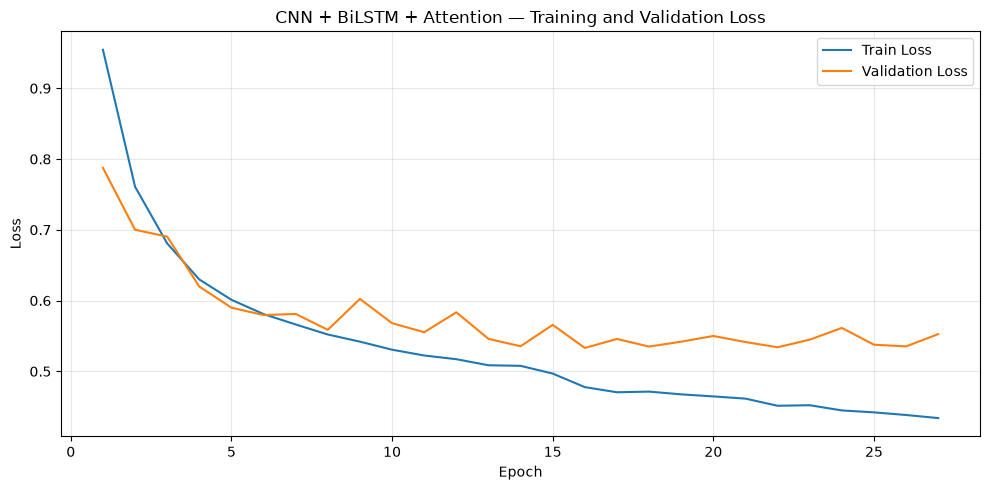

In [49]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "CNN + BiLSTM + Attention — Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

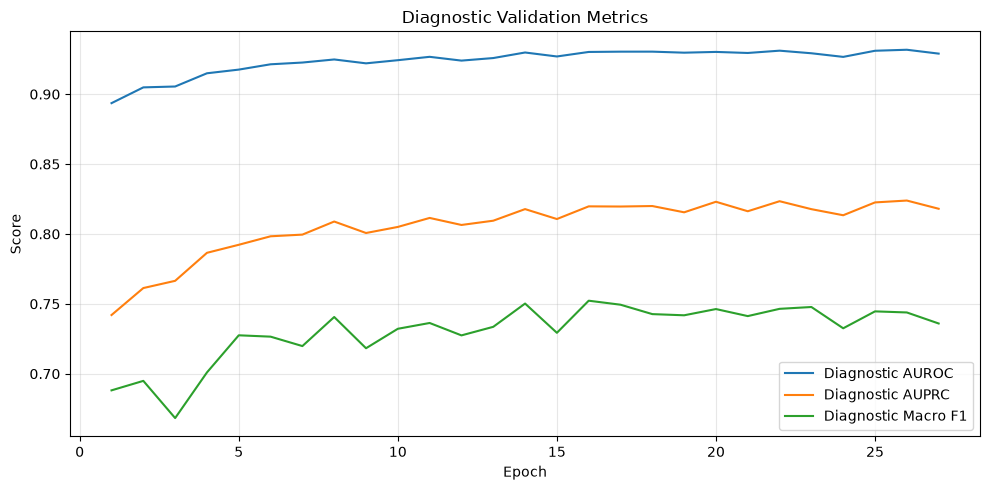

In [50]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["epoch"],
    history_df[
        "diagnostic_auroc"
    ],
    label="Diagnostic AUROC",
)

plt.plot(
    history_df["epoch"],
    history_df[
        "diagnostic_auprc"
    ],
    label="Diagnostic AUPRC",
)

plt.plot(
    history_df["epoch"],
    history_df[
        "diagnostic_f1"
    ],
    label="Diagnostic Macro F1",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Diagnostic Validation Metrics"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

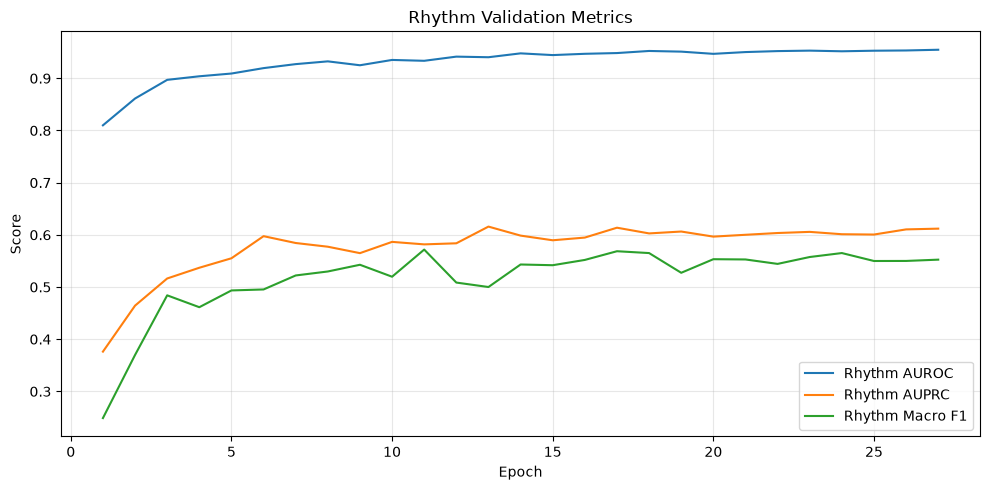

In [51]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["epoch"],
    history_df[
        "rhythm_auroc"
    ],
    label="Rhythm AUROC",
)

plt.plot(
    history_df["epoch"],
    history_df[
        "rhythm_auprc"
    ],
    label="Rhythm AUPRC",
)

plt.plot(
    history_df["epoch"],
    history_df[
        "rhythm_f1"
    ],
    label="Rhythm Macro F1",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Rhythm Validation Metrics"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

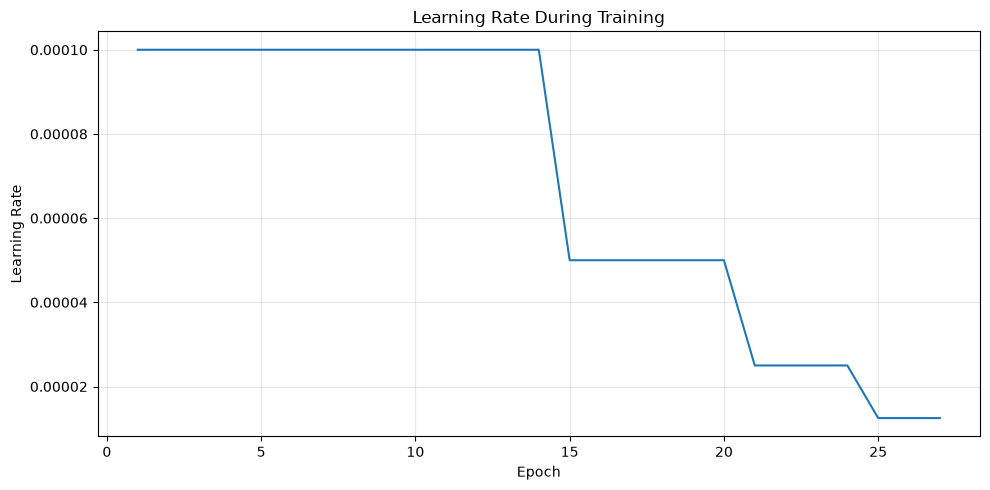

In [52]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["epoch"],
    history_df[
        "learning_rate"
    ],
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Learning Rate"
)

plt.title(
    "Learning Rate During Training"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [53]:
if best_state is None:

    raise RuntimeError(
        "Best model state was not created."
    )


model.load_state_dict(
    best_state
)

model.eval()


print(
    "Best model restored."
)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation score:",
    best_score
)

Best model restored.
Best epoch: 17
Best validation score: 0.6590014836450152


In [54]:
validation_output = evaluate(
    model,
    val_loader,
)


validation_diagnostic_true = (
    validation_output[
        "diagnostic_true"
    ]
)

validation_diagnostic_probs = (
    validation_output[
        "diagnostic_probs"
    ]
)


validation_rhythm_true = (
    validation_output[
        "rhythm_true"
    ]
)

validation_rhythm_probs = (
    validation_output[
        "rhythm_probs"
    ]
)

In [55]:
def find_optimal_thresholds(
    y_true,
    y_prob,
):

    thresholds = []

    best_f1_values = []

    grid = np.linspace(
        0.05,
        0.95,
        91
    )


    for i in range(
        y_true.shape[1]
    ):

        true = y_true[:, i]
        prob = y_prob[:, i]


        if len(
            np.unique(true)
        ) < 2:

            thresholds.append(
                0.5
            )

            best_f1_values.append(
                np.nan
            )

            continue


        best_threshold = 0.5
        best_f1 = -1.0


        for threshold in grid:

            prediction = (
                prob >= threshold
            ).astype(int)


            score = f1_score(
                true,
                prediction,
                zero_division=0
            )


            if score > best_f1:

                best_f1 = score

                best_threshold = (
                    threshold
                )


        thresholds.append(
            best_threshold
        )

        best_f1_values.append(
            best_f1
        )


    return (
        np.asarray(
            thresholds,
            dtype=np.float32
        ),

        np.asarray(
            best_f1_values,
            dtype=np.float32
        ),
    )

In [56]:
(
    diagnostic_thresholds,
    diagnostic_validation_f1,
) = find_optimal_thresholds(

    validation_diagnostic_true,

    validation_diagnostic_probs,
)


diagnostic_threshold_table = (
    pd.DataFrame({

        "label":
            diagnostic_targets,

        "threshold":
            diagnostic_thresholds,

        "validation_f1":
            diagnostic_validation_f1,
    })
)


display(
    diagnostic_threshold_table
)

,label,threshold,validation_f1
0,NORM,0.78,0.864536
1,MI,0.42,0.752153
2,STTC,0.37,0.759212
3,CD,0.44,0.766739
4,HYP,0.50,0.637899


In [57]:
(
    rhythm_thresholds,
    rhythm_validation_f1,
) = find_optimal_thresholds(

    validation_rhythm_true,

    validation_rhythm_probs,
)


rhythm_threshold_table = (
    pd.DataFrame({

        "label":
            rhythm_targets,

        "threshold":
            rhythm_thresholds,

        "validation_f1":
            rhythm_validation_f1,
    })
)


display(
    rhythm_threshold_table
)

,label,threshold,validation_f1
0,RHYTHM_SR,0.41,0.941040
1,RHYTHM_AFIB,0.77,0.871795
2,RHYTHM_AFLT,0.95,0.833333
3,RHYTHM_STACH,0.53,0.802260
4,RHYTHM_SBRAD,0.68,0.666667
5,RHYTHM_SARRH,0.27,0.201493
6,RHYTHM_PSVT,0.44,0.400000
7,RHYTHM_BIGU,0.33,0.312500
8,RHYTHM_PACE,0.59,0.862069


In [58]:
test_output = evaluate(
    model,
    test_loader,
)


test_diagnostic_true = (
    test_output[
        "diagnostic_true"
    ]
)

test_diagnostic_probs = (
    test_output[
        "diagnostic_probs"
    ])


test_rhythm_true = (
    test_output[
        "rhythm_true"
    ]
)

test_rhythm_probs = (
    test_output[
        "rhythm_probs"
    ]
)


print(
    "Test records evaluated:",
    len(
        test_diagnostic_true
    )
)

Test records evaluated: 2203


In [59]:
test_diagnostic_metrics = (
    multilabel_metrics(

        test_diagnostic_true,

        test_diagnostic_probs,

        diagnostic_thresholds,
    )
)


print(
    "=" * 70
)

print(
    "DIAGNOSTIC TEST RESULTS"
)

print(
    "=" * 70
)


for key, value in (
    test_diagnostic_metrics.items()
):

    print(
        f"{key:<12}: "
        f"{value:.6f}"
    )

DIAGNOSTIC TEST RESULTS
auroc       : 0.925416
auprc       : 0.815309
f1          : 0.742128
precision   : 0.751426
recall      : 0.738740
micro_f1    : 0.773941


In [60]:
test_rhythm_metrics = (
    multilabel_metrics(

        test_rhythm_true,

        test_rhythm_probs,

        rhythm_thresholds,
    )
)


print(
    "=" * 70
)

print(
    "RHYTHM TEST RESULTS"
)

print(
    "=" * 70
)


for key, value in (
    test_rhythm_metrics.items()
):

    print(
        f"{key:<12}: "
        f"{value:.6f}"
    )

RHYTHM TEST RESULTS
auroc       : 0.921660
auprc       : 0.583981
f1          : 0.550995
precision   : 0.598687
recall      : 0.637930
micro_f1    : 0.849799


In [61]:
def per_label_report(
    y_true,
    y_prob,
    thresholds,
    labels,
):

    rows = []


    for i, label in enumerate(
        labels
    ):

        true = y_true[:, i]

        prob = y_prob[:, i]

        threshold = thresholds[i]

        prediction = (
            prob >= threshold
        ).astype(int)


        if len(
            np.unique(true)
        ) < 2:

            auroc = np.nan

            auprc = np.nan

        else:

            auroc = roc_auc_score(
                true,
                prob
            )

            auprc = (
                average_precision_score(
                    true,
                    prob
                )
            )


        tn, fp, fn, tp = (
            confusion_matrix(
                true,
                prediction,
                labels=[0, 1],
            )
            .ravel()
        )


        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )


        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )


        rows.append({

            "label":
                label,

            "AUROC":
                auroc,

            "AUPRC":
                auprc,

            "F1":
                f1_score(
                    true,
                    prediction,
                    zero_division=0,
                ),

            "Precision":
                precision_score(
                    true,
                    prediction,
                    zero_division=0,
                ),

            "Recall":
                recall_score(
                    true,
                    prediction,
                    zero_division=0,
                ),

            "Sensitivity":
                sensitivity,

            "Specificity":
                specificity,

            "Positive support":
                int(true.sum()),

            "Threshold":
                threshold,
        })


    return pd.DataFrame(
        rows
    )

In [62]:
diagnostic_report = (
    per_label_report(

        test_diagnostic_true,

        test_diagnostic_probs,

        diagnostic_thresholds,

        diagnostic_targets,
    )
)


display(
    diagnostic_report
)

,label,AUROC,AUPRC,F1,Precision,Recall,Sensitivity,Specificity,Positive support,Threshold
0,NORM,0.948165,0.925640,0.859113,0.818011,0.904564,0.904564,0.843422,964,0.78
1,MI,0.919427,0.822991,0.716730,0.755511,0.681736,0.681736,0.926061,553,0.42
2,STTC,0.929271,0.807906,0.763276,0.721088,0.810707,0.810707,0.902381,523,0.37
3,CD,0.920459,0.840215,0.750831,0.837037,0.680723,0.680723,0.961290,498,0.44
4,HYP,0.909759,0.679793,0.620690,0.625483,0.615970,0.615970,0.950000,263,0.50


In [63]:
rhythm_report = (
    per_label_report(

        test_rhythm_true,

        test_rhythm_probs,

        rhythm_thresholds,

        rhythm_targets,
    )
)


display(
    rhythm_report
)

,label,AUROC,AUPRC,F1,Precision,Recall,Sensitivity,Specificity,Positive support,Threshold
0,RHYTHM_SR,0.861690,0.936209,0.924000,0.887486,0.963647,0.963647,0.609524,1678,0.41
1,RHYTHM_AFIB,0.980100,0.867873,0.835526,0.835526,0.835526,0.835526,0.987811,152,0.77
2,RHYTHM_AFLT,0.953227,0.599440,0.444444,1.000000,0.285714,0.285714,1.000000,7,0.95
3,RHYTHM_STACH,0.991761,0.880617,0.855556,0.785714,0.939024,0.939024,0.990099,82,0.53
4,RHYTHM_SBRAD,0.949692,0.523760,0.491525,0.537037,0.453125,0.453125,0.988312,64,0.68
5,RHYTHM_SARRH,0.723192,0.113451,0.181159,0.125628,0.324675,0.324675,0.918156,77,0.27
6,RHYTHM_PSVT,0.998637,0.325000,0.222222,0.125000,1.000000,1.000000,0.993639,2,0.44
7,RHYTHM_BIGU,0.880752,0.223763,0.235294,0.222222,0.250000,0.250000,0.996811,8,0.33
8,RHYTHM_PACE,0.955889,0.785712,0.769231,0.869565,0.689655,0.689655,0.998620,29,0.59


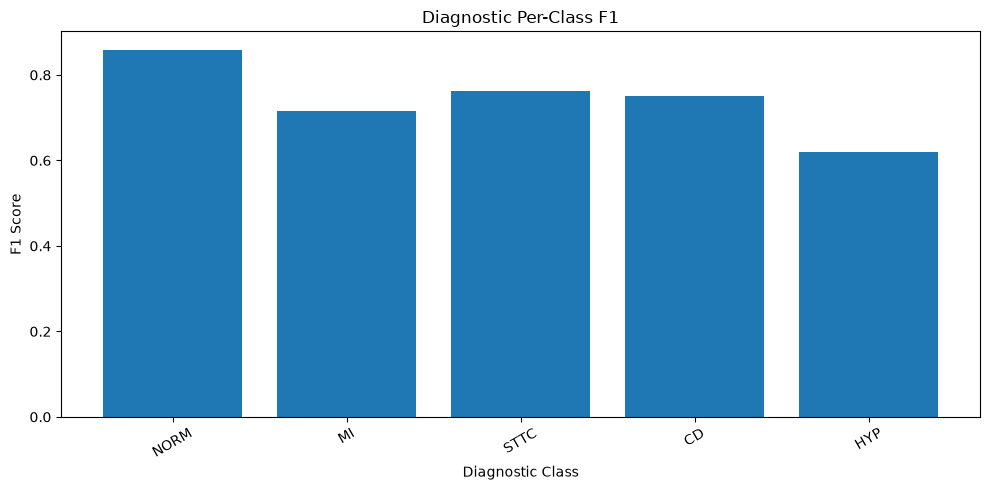

In [64]:
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    diagnostic_report[
        "label"
    ],

    diagnostic_report[
        "F1"
    ],
)

plt.xlabel(
    "Diagnostic Class"
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "Diagnostic Per-Class F1"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()

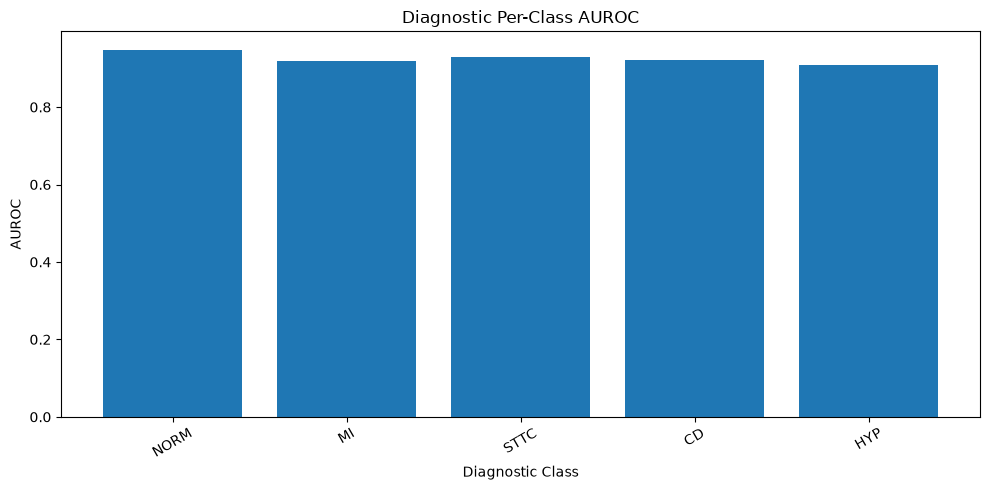

In [65]:
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    diagnostic_report[
        "label"
    ],

    diagnostic_report[
        "AUROC"
    ],
)

plt.xlabel(
    "Diagnostic Class"
)

plt.ylabel(
    "AUROC"
)

plt.title(
    "Diagnostic Per-Class AUROC"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()

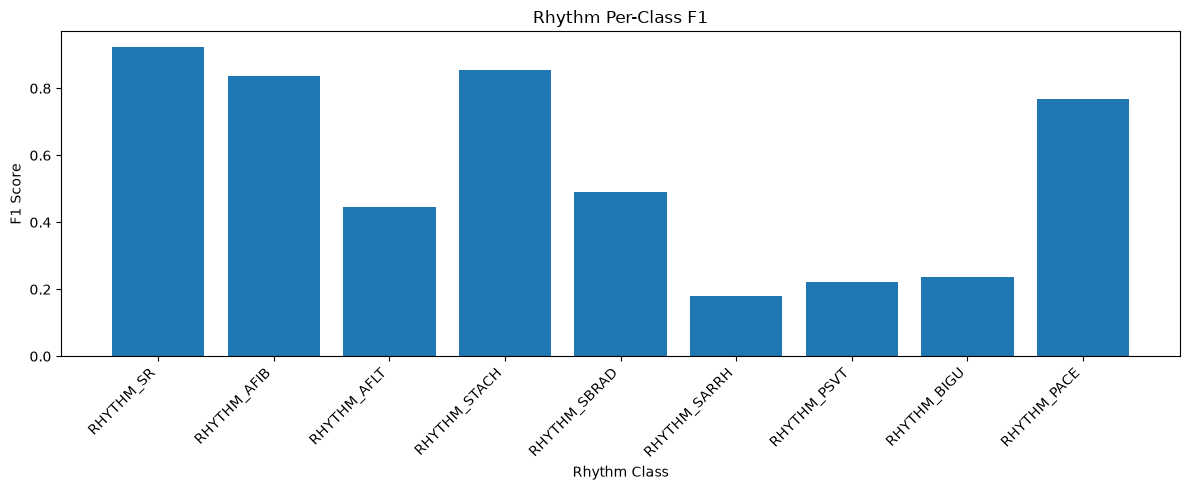

In [66]:
plt.figure(
    figsize=(12, 5)
)

plt.bar(
    rhythm_report[
        "label"
    ],

    rhythm_report[
        "F1"
    ],
)

plt.xlabel(
    "Rhythm Class"
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "Rhythm Per-Class F1"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [67]:
CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "ecg"
    / "ptbxl"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


RESULTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "ecg"
    / "cnn_bilstm_attention"
)


RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Checkpoint directory:",
    CHECKPOINT_DIR
)

print(
    "\nResults directory:",
    RESULTS_DIR
)

Checkpoint directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\ecg\ptbxl

Results directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\cnn_bilstm_attention


In [68]:
checkpoint_path = (
    CHECKPOINT_DIR
    /
    f"ptbxl_cnn_bilstm_attention_"
    f"{PREPROCESSING_VERSION}.pt"
)


checkpoint = {

    "model_state_dict":
        model.state_dict(),

    "model_config":
        MODEL_CONFIG,

    "train_config":
        TRAIN_CONFIG,

    "augmentation_config":
        AUGMENTATION_CONFIG,

    "preprocessing_version":
        PREPROCESSING_VERSION,

    "preprocessing_config":
        preprocessing_config,

    "signal_length":
        SIGNAL_LENGTH,

    "num_leads":
        NUM_LEADS,

    "diagnostic_targets":
        diagnostic_targets,

    "rhythm_targets":
        rhythm_targets,

    "diagnostic_thresholds":
        diagnostic_thresholds,

    "rhythm_thresholds":
        rhythm_thresholds,

    "best_epoch":
        best_epoch,

    "best_validation_score":
        best_score,

    "seed":
        SEED,
}


torch.save(
    checkpoint,
    checkpoint_path
)


print(
    "Checkpoint saved:"
)

print(
    checkpoint_path
)

Checkpoint saved:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\ecg\ptbxl\ptbxl_cnn_bilstm_attention_100hz_record_zscore.pt


In [69]:
history_path = (
    RESULTS_DIR
    / "training_history.csv"
)


history_df.to_csv(
    history_path,
    index=False
)


print(
    "Saved:",
    history_path
)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\cnn_bilstm_attention\training_history.csv


In [70]:
diagnostic_results_path = (
    RESULTS_DIR
    / "diagnostic_per_label.csv"
)


diagnostic_report.to_csv(
    diagnostic_results_path,
    index=False
)


print(
    "Saved:",
    diagnostic_results_path
)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\cnn_bilstm_attention\diagnostic_per_label.csv


In [71]:
rhythm_results_path = (
    RESULTS_DIR
    / "rhythm_per_label.csv"
)


rhythm_report.to_csv(
    rhythm_results_path,
    index=False
)


print(
    "Saved:",
    rhythm_results_path
)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\cnn_bilstm_attention\rhythm_per_label.csv


In [72]:
thresholds_path = (
    RESULTS_DIR
    / "thresholds.npz"
)


np.savez(
    thresholds_path,

    diagnostic=
        diagnostic_thresholds,

    rhythm=
        rhythm_thresholds,
)


print(
    "Saved:",
    thresholds_path
)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\cnn_bilstm_attention\thresholds.npz


In [73]:
final_metrics = {

    "model":
        "CNN_BiLSTM_Attention",

    "dataset":
        "PTB-XL",

    "preprocessing_version":
        PREPROCESSING_VERSION,

    "input_shape":
        [
            NUM_LEADS,
            SIGNAL_LENGTH
        ],

    "diagnostic_targets":
        diagnostic_targets,

    "rhythm_targets":
        rhythm_targets,

    "best_epoch":
        int(best_epoch),

    "best_validation_score":
        float(best_score),

    "diagnostic_test":
        {
            key:
                float(value)

            for key, value

            in test_diagnostic_metrics.items()
        },

    "rhythm_test":
        {
            key:
                float(value)

            for key, value

            in test_rhythm_metrics.items()
        },

    "patient_overlap":
        {
            "train_val":
                len(train_val_overlap),

            "train_test":
                len(train_test_overlap),

            "val_test":
                len(val_test_overlap),
        },
}


metrics_path = (
    RESULTS_DIR
    / "test_metrics.json"
)


with open(
    metrics_path,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        final_metrics,
        f,
        indent=2
    )


print(
    json.dumps(
        final_metrics,
        indent=2
    )
)

{
  "model": "CNN_BiLSTM_Attention",
  "dataset": "PTB-XL",
  "preprocessing_version": "100hz_record_zscore",
  "input_shape": [
    12,
    1000
  ],
  "diagnostic_targets": [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP"
  ],
  "rhythm_targets": [
    "RHYTHM_SR",
    "RHYTHM_AFIB",
    "RHYTHM_AFLT",
    "RHYTHM_STACH",
    "RHYTHM_SBRAD",
    "RHYTHM_SARRH",
    "RHYTHM_PSVT",
    "RHYTHM_BIGU",
    "RHYTHM_PACE"
  ],
  "best_epoch": 17,
  "best_validation_score": 0.6590014836450152,
  "diagnostic_test": {
    "auroc": 0.9254162502508538,
    "auprc": 0.8153090382955381,
    "f1": 0.742127977220931,
    "precision": 0.7514260753947095,
    "recall": 0.7387400462360867,
    "micro_f1": 0.7739409042363831
  },
  "rhythm_test": {
    "auroc": 0.9216598920159265,
    "auprc": 0.5839805006694022,
    "f1": 0.5509953632120214,
    "precision": 0.5986866108524811,
    "recall": 0.6379297430981404,
    "micro_f1": 0.8497988377291015
  },
  "patient_overlap": {
    "train_val": 0,
 

In [74]:
experiment_config = {

    "seed":
        SEED,

    "dataset":
        "PTB-XL",

    "model":
        MODEL_CONFIG,

    "preprocessing_version":
        PREPROCESSING_VERSION,

    "preprocessing_config":
        preprocessing_config,

    "training":
        TRAIN_CONFIG,

    "augmentation":
        AUGMENTATION_CONFIG,

    "diagnostic_targets":
        diagnostic_targets,

    "rhythm_targets":
        rhythm_targets,

    "signal_length":
        SIGNAL_LENGTH,

    "num_leads":
        NUM_LEADS,

    "loss":
        {
            "type":
                "BCEWithLogitsLoss",

            "diagnostic_task_weight":
                DIAGNOSTIC_TASK_WEIGHT,

            "rhythm_task_weight":
                RHYTHM_TASK_WEIGHT,
        },
}


experiment_config_path = (
    RESULTS_DIR
    / "experiment_config.json"
)


with open(
    experiment_config_path,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        experiment_config,
        f,
        indent=2
    )


print(
    "Saved:",
    experiment_config_path
)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\cnn_bilstm_attention\experiment_config.json


In [75]:
model.eval()


sample = test_dataset[0]


sample_signal = (
    sample["signal"]
    .unsqueeze(0)
    .to(DEVICE)
)


with torch.no_grad():

    sample_output = (
        model(
            sample_signal
        )
    )


attention_weights = (
    sample_output[
        "attention"
    ]
    .squeeze()
    .cpu()
    .numpy()
)


print(
    "Attention shape:",
    attention_weights.shape
)

Attention shape: (250,)


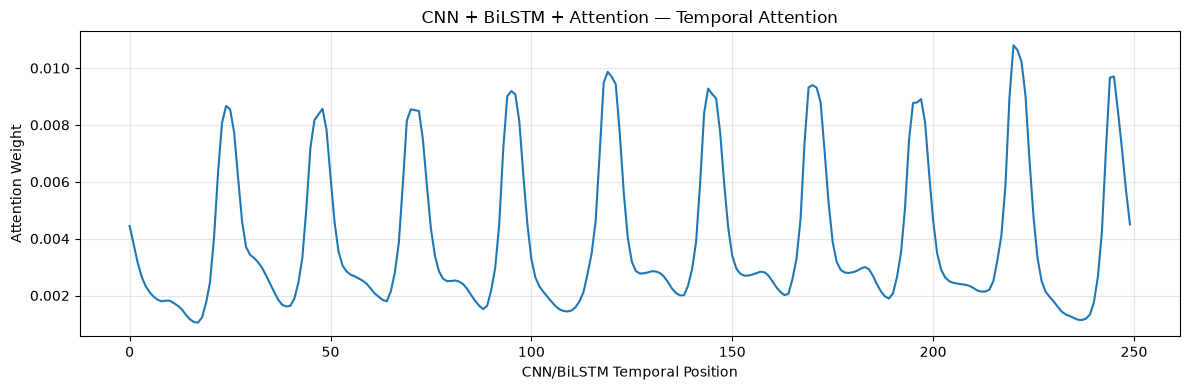

In [76]:
plt.figure(
    figsize=(12, 4)
)

plt.plot(
    attention_weights
)

plt.xlabel(
    "CNN/BiLSTM Temporal Position"
)

plt.ylabel(
    "Attention Weight"
)

plt.title(
    "CNN + BiLSTM + Attention — Temporal Attention"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [77]:
print(
    "Minimum attention:",
    attention_weights.min()
)

print(
    "Maximum attention:",
    attention_weights.max()
)

print(
    "Mean attention:",
    attention_weights.mean()
)

print(
    "Sum attention:",
    attention_weights.sum()
)

Minimum attention: 0.0010460496
Maximum attention: 0.010804505
Mean attention: 0.0039999997
Sum attention: 0.99999994


In [78]:
checks = {

    "Train/Val patient overlap":
        len(train_val_overlap) == 0,

    "Train/Test patient overlap":
        len(train_test_overlap) == 0,

    "Val/Test patient overlap":
        len(val_test_overlap) == 0,

    "12 ECG leads":
        NUM_LEADS == 12,

    "1000 samples":
        SIGNAL_LENGTH == 1000,

    "Five diagnostic labels":
        len(diagnostic_targets) == 5,

    "Rhythm labels loaded":
        len(rhythm_targets) > 0,

    "Checkpoint exists":
        checkpoint_path.exists(),

    "Metrics file exists":
        metrics_path.exists(),

    "Threshold file exists":
        thresholds_path.exists(),

    "All test records evaluated":
        len(
            test_diagnostic_true
        )
        ==
        len(test_dataset),
}


for name, passed in (
    checks.items()
):

    status = (
        "PASS"
        if passed
        else
        "FAIL"
    )

    print(
        f"[{status}] {name}"
    )


if not all(
    checks.values()
):

    raise RuntimeError(
        "One or more integrity checks failed."
    )


print(
    "\nAll integrity checks passed."
)

[PASS] Train/Val patient overlap
[PASS] Train/Test patient overlap
[PASS] Val/Test patient overlap
[PASS] 12 ECG leads
[PASS] 1000 samples
[PASS] Five diagnostic labels
[PASS] Rhythm labels loaded
[PASS] Checkpoint exists
[PASS] Metrics file exists
[PASS] Threshold file exists
[PASS] All test records evaluated

All integrity checks passed.


In [79]:
print("=" * 80)

print(
    "PTB-XL CNN + BiLSTM + ATTENTION"
)

print(
    "TRAINING COMPLETE"
)

print("=" * 80)


print(
    f"Model             : "
    f"CNN + BiLSTM + Attention"
)

print(
    f"Input             : "
    f"{NUM_LEADS} leads × "
    f"{SIGNAL_LENGTH} samples"
)

print(
    f"Preprocessing     : "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Diagnostic labels : "
    f"{len(diagnostic_targets)}"
)

print(
    f"Rhythm labels     : "
    f"{len(rhythm_targets)}"
)

print(
    f"Best epoch        : "
    f"{best_epoch}"
)

print(
    f"Diagnostic AUROC  : "
    f"{test_diagnostic_metrics['auroc']:.4f}"
)

print(
    f"Diagnostic AUPRC  : "
    f"{test_diagnostic_metrics['auprc']:.4f}"
)

print(
    f"Diagnostic Macro F1: "
    f"{test_diagnostic_metrics['f1']:.4f}"
)

print(
    f"Rhythm AUROC      : "
    f"{test_rhythm_metrics['auroc']:.4f}"
)

print(
    f"Rhythm AUPRC      : "
    f"{test_rhythm_metrics['auprc']:.4f}"
)

print(
    f"Rhythm Macro F1   : "
    f"{test_rhythm_metrics['f1']:.4f}"
)

print()
print(
    "Checkpoint:"
)

print(
    checkpoint_path
)

print()
print(
    "Metrics:"
)

print(
    metrics_path
)

PTB-XL CNN + BiLSTM + ATTENTION
TRAINING COMPLETE
Model             : CNN + BiLSTM + Attention
Input             : 12 leads × 1000 samples
Preprocessing     : 100hz_record_zscore
Diagnostic labels : 5
Rhythm labels     : 9
Best epoch        : 17
Diagnostic AUROC  : 0.9254
Diagnostic AUPRC  : 0.8153
Diagnostic Macro F1: 0.7421
Rhythm AUROC      : 0.9217
Rhythm AUPRC      : 0.5840
Rhythm Macro F1   : 0.5510

Checkpoint:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\ecg\ptbxl\ptbxl_cnn_bilstm_attention_100hz_record_zscore.pt

Metrics:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\cnn_bilstm_attention\test_metrics.json
